## music service chatbot

### 목적 : 
- 차량 운전중 음악 추천 
- 날씨에 어울리는 음악 추천
- A곡과 비슷한 B곡 추천
- PDF 기반 검색
- 수집된 데이터 기반 python 코드 활용 차트 비교
- CS 상담



Q : 오늘 날씨에 어울리는 재즈 추천해줘, 내가 사는 곳은 서울이야

feedback_node : no

plan_node : 

[오늘 서울 날씨에 어울리는 재즈 음악 목록을 생성합니다.

생성된 음악 목록에서 서비스에서 이용 가능한 음악을 검증합니다.

최종 음악 목록을 선정하여 추천합니다.]

start_node -> routing

final_node -> tool 사용 여부 확인

A :  web_search_agent 사용하여 진행할까여 ?

Q : 응 검색해

feedback_node : yes

start_node -> routing

agent 사용 -> 검색 결과 제시

final_node -> 검색 내용 기반 최종 답변

A :  web_search_agent,  query: 오늘 서울 날씨


### 기본 구성

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *
from module.db_query import *
from module.data_analysis import *
from module.plan import *

In [2]:
start_langsmith("final_music_1")

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music_1


In [3]:
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
    RemoveMessage,
)
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

### main graph

In [4]:
path_template = """
    # System :
    You are an AI assistant 
    You can judge the user's input and Ai answer, make decisions

    # Previous AI Answers :
    {answer}

    # User input :
    {question}

    
    # Rules :
    Output 'response_node' when a request is received to agree or accept the Prevalent AI Answers

    Otherwise, output 'request_node' if the value of 'quest' is a new proposal, a suggestion that does not matter to Prevalent AI Answers

    In the case of 'response_node', we will try to resolve your request using agent.

    In the case of 'request_node', we will be responsible for developing a plan to resolve the proposal.

    # Important :
    The answer must be one of three
    The answer is available in Korean
"""
path_prompt = ChatPromptTemplate.from_template(path_template)

inspection_template = """ 
    # System : 
   If you request a change to a different tool than the existing one, we recommend a different tool.
    If not, use existing tools

    You have some agents :
    1. The first agent is the agent for web search. Most requests can be resolved through web search

    2. The second agent is the Database agent. To provide music services, we can use a database that can manage, inquire, and manage the sales performance of artists and music.
    
    3. The third agent can be visualized through data analysis requests and comparisons. By generating the Python code, it is possible to generate bar charts, donut charts, and line graphs based on this.
        
    4. other 'conversation_agent'.Agent that conducts a normal conversation. 
    It is very important to identify the user's requirements and use an agent that fits the situation

    # AI Answer : 
    {answer}

    # Task :
    {current_step}

    # User's request :
    {question}

    # Important :
    We are going to solve the given `next_task` using agent.
    Make sure to solve the problem without asking the user for additional information.
"""
inspection_prompt = ChatPromptTemplate.from_template(inspection_template)

In [5]:
def web_search_agent(state: State):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {text}" for i, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {plan_str} \n\n You are tasked with executing [step 1. {task}]."""
    prompt = get_prompt_web()
    llm = get_gemini()
    tavily = get_tavily_tool()
    tools = [tavily, get_weather]
    web_agent = create_react_agent(model=llm, tools=tools, prompt=prompt)
    result = web_agent.invoke({"messages": task_str})
    latest_messages = f" Question :{task}\n Response :{result['messages'][-1].content}"
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})

In [6]:
def inspection_node(state: State):
    # answer와 current_steps, question 을 사용하여 next_agent 확인 단계
    answer = state.get("answer")
    current_step = state.get("current_step")
    question = state.get("question")
    llm = get_gpt()
    chain = inspection_prompt | llm.with_structured_output(RouteModel)
    result = chain.invoke(
        {"answer": answer, "current_step": current_step, "question": question}
    )
    next_agent = result.datasource
    return State({"next_agent": next_agent})


def summary_node(state: State):
    messages = state["messages"]
    if len(messages) > 6:
        summary = state.get("summary", "")
        # 이전 요약 정보가 있다면 요약 메시지 생성
        if summary:
            summary_message = (
                f"This is summary of the conversation to date: {summary}\n\n"
                "Extend the summary by taking into account the new messages above in Korean:"
            )
        else:
            # 요약 메시지 생성
            summary_message = "Create a summary of the conversation above in Korean:"

        # 요약 메시지와 이전 메시지 결합
        messages = state["messages"] + [HumanMessage(content=summary_message)]
        # 모델 호출
        response = get_gemini().invoke(messages)
        # 오래된 메시지 삭제
        delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
        # 요약 정보 반환
        return {"summary": response.content, "messages": delete_messages}
    else:
        return State({})

In [7]:
def is_routing_agent(
    state: State,
) -> Literal["db_graph", "data_analysis_graph", "conversation_agent"]:
    next_agent = state.get("next_agent")
    if next_agent == "db_agent":
        return "db_graph"
    elif next_agent == "data_analysis":
        return "data_analysis_graph"
    else:
        return "conversation_agent"

In [8]:
db_graph = get_db_graph()
data_analysis_graph = get_data_analsys_graph()
plan_graph = get_plan_graph()

In [9]:
state_graph = StateGraph(State)
state_graph.add_node("inspection_node", inspection_node)
state_graph.add_node("summary_node", summary_node)
state_graph.add_node("conversation_agent", plan_graph)
state_graph.add_node("data_analysis_graph", data_analysis_graph)
state_graph.add_node("db_graph", db_graph)

state_graph.add_edge(START, "inspection_node")
state_graph.add_edge("inspection_node", "summary_node")
state_graph.add_conditional_edges(source="summary_node", path=is_routing_agent)
state_graph.add_edge("conversation_agent", END)
state_graph.add_edge("data_analysis_graph", END)
state_graph.add_edge("db_graph", END)


cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

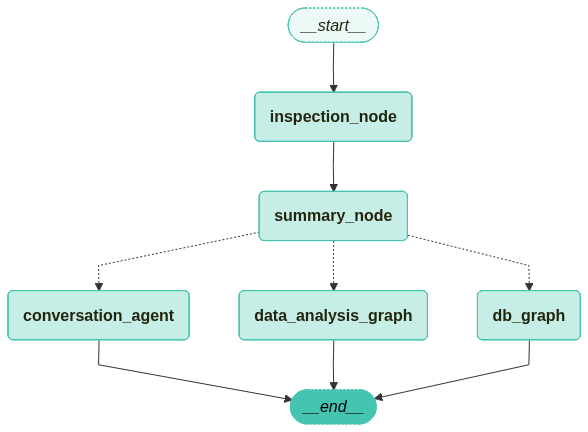

In [10]:
visualize_graph(graph)

In [11]:
def message_parser(event):
    print("=========" * 10 + "\n\n")
    print(f"question : {event['question']}\n")
    print(f"human_feedback : {event.get('human_feedback')}\n")
    print(f"next_agent : {event.get('next_agent')}\n")
    print(f"plan : {event.get('plan')}\n")
    print(f"past_steps : {event.get('past_steps')}\n")
    print(f"messages : {get_messages(event)}\n")
    print(f"answer : {event.get('answer')}\n")
    print("=========" * 10 + "\n\n")


def get_messages(event):
    messages = event.get("messages")
    if len(messages) == 0:
        return ""
    else:
        return messages[-1]


def parse_messages(messages):
    parsed = []
    for msg in messages:
        if isinstance(msg, HumanMessage):
            parsed.append(f"human : {msg.content}")
        elif isinstance(msg, AIMessage):
            parsed.append(f"ai : {msg.content}")
        elif isinstance(msg, ToolMessage):
            parsed.append(f"tool : {msg.content}")
        else:
            parsed.append(f"etc : {msg.content}")
    return parsed

In [12]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())

question = "안녕 난 Kara Nielsen 이야"
inputs = {"question": question, "messages": question}

for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

In [13]:
first_snapshot = graph.get_state(config)
# parse_messages(first_snapshot.values["messages"])
first_snapshot.values

{'question': '안녕 난 Kara Nielsen 이야',
 'plan': ['안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?'],
 'messages': [HumanMessage(content='안녕 난 Kara Nielsen 이야', additional_kwargs={}, response_metadata={}, id='11cfdda1-7b69-4620-8488-d9899d7ac6ad'),
  HumanMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='aa3e9d9a-b010-4a41-a923-78d2cdfa7dc7'),
  AIMessage(content='실행 계획 : 안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요? \n 사용 도구 : conversation_agent', additional_kwargs={}, response_metadata={}, id='d175ea12-5f2d-400e-a00b-0f8a176082b2'),
  AIMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--ec455c11-4022-4300-8922-8fcd12a06889-0', usage_metadata={'input_tokens': 205, 'output_tokens': 12, 'total_tokens': 217, 'input_token_details': {'cache_read': 0}})],
 'current_steps'

In [14]:
question = "내 FavoriteMusic 어떤 곡이 존재하는지 알려줘"
inputs = {"question": question, "messages": question}
for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

BadRequestError: Error code: 400 - {'error': {'message': "Invalid parameter: messages with role 'tool' must be a response to a preceeding message with 'tool_calls'.", 'type': 'invalid_request_error', 'param': 'messages.[0].role', 'code': None}}

In [ ]:
second_snapshot = graph.get_state(config)
# parse_messages(second_snapshot.values["messages"])
second_snapshot.values

In [ ]:
# question = "내 FavoriteMusic 어떤 곡이 존재하는지 알려줘"
# inputs = {"question": question, "messages": question}
# for event in graph.stream(inputs, config=config, stream_mode="values"):
#     pass